<a href="https://colab.research.google.com/github/jmprzybysz/Research-Data/blob/main/Pourbaix.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Welcome to the Pouraix diagram plotting noteboook!
Here, you will first pull the data for your material of interest from the Materials Project(MP) database, then plot it to see if what you got is what you want, and finally save the data locally on your computer, so that you can pretty-plot in Origin.

To get Pourbaix diagram data for your material, you will need your individual MP API key. You can find it on the MP website, after you log into your account there. Click "API" in the top right corner and copy-paste the code into the corresponding field in the code.  

Once you have your API key, go through the code and see where the comments in
<font color="green">#green</font> tell you to input the key and query data (element name, element ratios, concentrations etc.).

Next, execute the code cells one by one from top to bottom. The order is necessary.





In [1]:
'''
First, we need to get some packages that are not in Google Collab by default.
'''
!pip -q install mp-api>=0.41 pymatgen>=2024.7 mpcontribs-client>=5.0

Retrieving ThermoDoc documents:   0%|          | 0/234 [00:00<?, ?it/s]

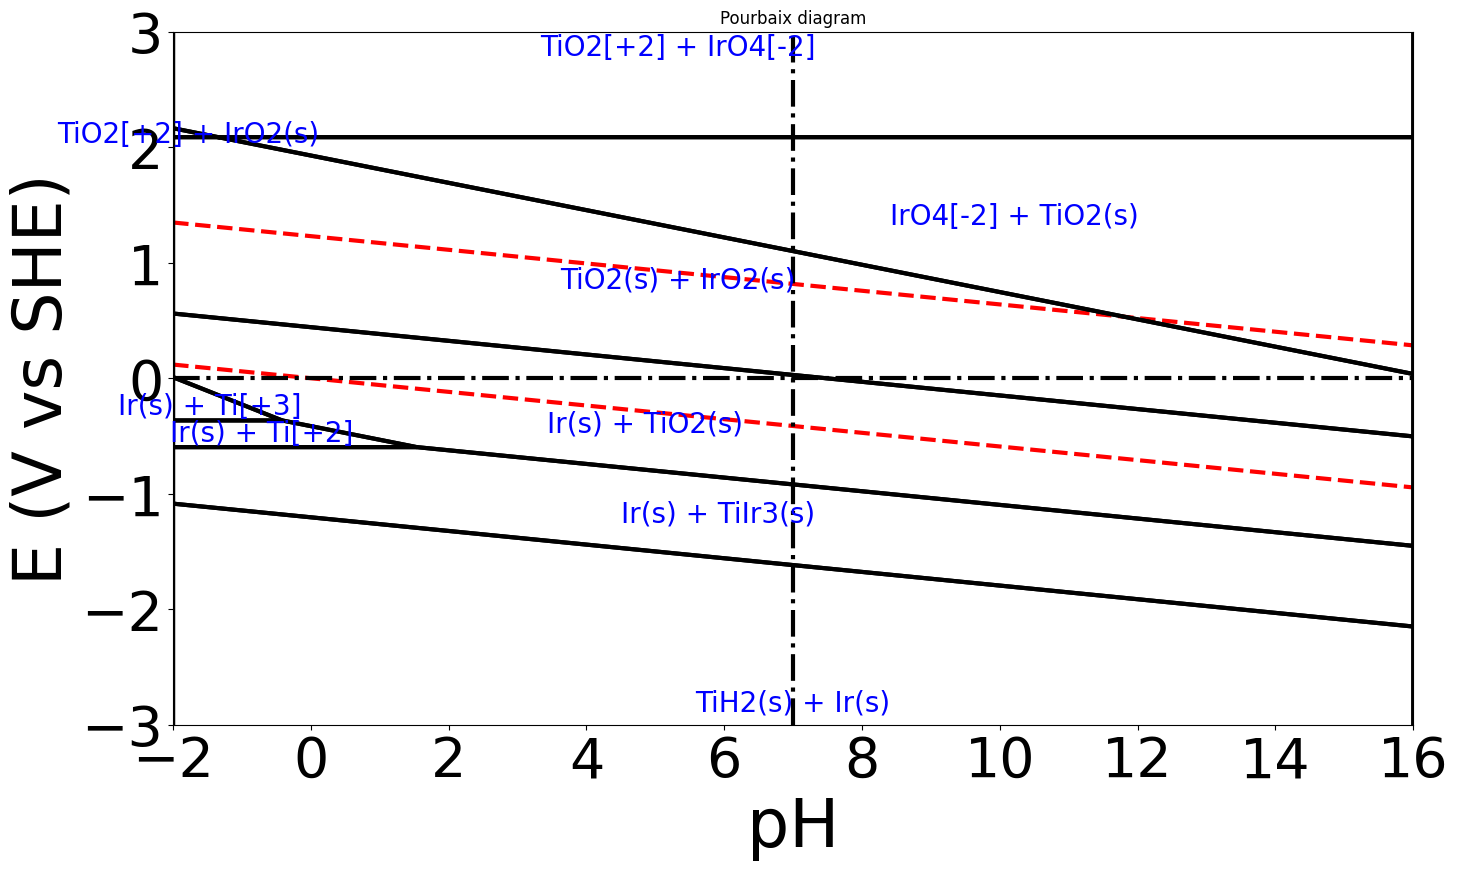

In [28]:
from mp_api.client import MPRester
from pymatgen.analysis.pourbaix_diagram import PourbaixDiagram, PourbaixPlotter
import matplotlib.pyplot as plt


API_KEY = "UxhYfuch6ZJPXS4v4bCbQ5EF9xsAjG49"  # put your Materials Project API key

with MPRester(API_KEY) as mpr:
    # Only list the non-aqueous elements; H and O are added automatically
    entries = mpr.get_pourbaix_entries(["Ir", "Ti"])

pbx_diagram = PourbaixDiagram(entries, comp_dict={"Ir": 90, "Ti": 10}, conc_dict={"Ir": 1e-4, "Ti": 1e-4})    # comp_dict sets element ratio. cocn_dict sets molar concentrations of ions.

plotter = PourbaixPlotter(pbx_diagram)
ax = plotter.get_pourbaix_plot()
ax.set_title("Pourbaix diagram")
ax.set_xlabel("pH"); ax.set_ylabel("E (V vs SHE)")
plt.show()

### Getting data to pretty-plot in Origin


In [29]:
# ==== Export per entry_id with robust vertex ordering; files contain only pH, E, vertex_idx ====
import re
import numpy as np
import pandas as pd
from pathlib import Path
from google.colab import files

# Limits used for the polygons (same as your plot)
limits = [[-2, 16], [-1.5, 2.0]]      # Define limits of the diagram in format: [[pH], [EVSHE]]

# Domains & raw vertices from pymatgen
domains, vertices = PourbaixDiagram.get_pourbaix_domains(
    pbx_diagram.stable_entries, limits=limits
)

def normalize_entry_id(eid):
    """Return a string key suitable for sort/group (handles list/tuple/np.ndarray)."""
    import numpy as _np
    if eid is None:
        return None
    if isinstance(eid, (list, tuple, set, _np.ndarray)):
        return "+".join(map(str, list(eid)))
    return str(eid)

def clean_name(s: str, maxlen: int = 80) -> str:
    s = re.sub(r"[^A-Za-z0-9._-]+", "_", str(s)).strip("._-")
    return (s[:maxlen] or "entry")

def order_vertices_ccw(pts, dedup_decimals=6, close=True):
    """
    Robustly order polygon vertices counter-clockwise.
    - Deduplicate by rounding (helps if repeated points are present).
    - Sort by angle around centroid.
    - Optionally close by appending the first vertex again.
    """
    P = np.asarray(pts, dtype=float)
    if P.ndim != 2 or P.shape[0] < 3:
        return P  # nothing to reorder
    if dedup_decimals is not None:
        P = np.unique(np.round(P, dedup_decimals), axis=0)
        if P.shape[0] < 3:
            return P
    c = P.mean(axis=0)  # [pH_center, E_center]
    ang = np.arctan2(P[:, 1] - c[1], P[:, 0] - c[0])
    order = np.argsort(ang)
    P_ord = P[order]
    if close:
        P_ord = np.vstack([P_ord, P_ord[0]])
    return P_ord

# Build rows with CCW ordering and explicit vertex_idx
rows = []
for entry, pts in vertices.items():
    # normalize entry_id for grouping; keep raw for summary
    raw_eid = getattr(entry, "entry_id", None)
    eid_key = normalize_entry_id(raw_eid)

    poly = order_vertices_ccw(pts, dedup_decimals=6, close=True)
    for i, (pH, E) in enumerate(poly):
        rows.append({
            "pH": float(pH),                 # Column 1
            "E_V_SHE": float(E),             # Column 2
            "vertex_idx": i,                 # Column 3 (CCW traversal; last row closes loop)
            "entry_id": raw_eid,             # kept only for grouping/summary; not written to files
            "entry_id_str": eid_key,         # kept only for grouping/summary; not written to files
        })

# Internal dataframe (has entry_id columns for grouping)
df_internal = pd.DataFrame(rows)

# Sort by normalized entry_id then vertex order (ascending)
df_internal = df_internal.sort_values(
    by=["entry_id_str", "vertex_idx", "pH", "E_V_SHE"],
    kind="mergesort"
).reset_index(drop=True)

# Output folder (Colab-friendly)
OUT_DIR = Path('/content/pourbaix_polygons_by_entry')
OUT_DIR.mkdir(parents=True, exist_ok=True)

# 1) Combined file with ONLY the three columns
combined_cols = ["pH", "E_V_SHE", "vertex_idx"]
df_internal[combined_cols].to_csv(OUT_DIR / "all_entries_polygons_by_vertex.csv", index=False)

# 2) One file per entry_id_str with ONLY the three columns
summary_rows = []
for key, g in df_internal.groupby("entry_id_str", dropna=False, sort=False):
    g_sorted = g.sort_values(by=["vertex_idx", "pH", "E_V_SHE"], kind="mergesort")
    fname = clean_name(key if pd.notna(key) else "unknown_entry") + ".csv"
    g_sorted[combined_cols].to_csv(OUT_DIR / fname, index=False)

    summary_rows.append({
        "file": fname,
        "entry_id": g_sorted["entry_id"].iloc[0],
        "entry_id_str": key,
        "n_rows": int(g_sorted.shape[0]),
    })

# 3) Summary file (keeps ids so you know which file is which)
pd.DataFrame(summary_rows, columns=["file","entry_id","entry_id_str","n_rows"])\
  .to_csv(OUT_DIR / "summary.csv", index=False)

print(f"Wrote {OUT_DIR}/ :")
print(" - all_entries_polygons_by_vertex.csv (pH, E_V_SHE, vertex_idx)")
print(" - one CSV per entry_id (same three columns)")
print(" - summary.csv")

# Optional: zip & download from Colab
!zip -r /content/pourbaix_export.zip "$OUT_DIR"
files.download('/content/pourbaix_export.zip')


Wrote /content/pourbaix_polygons_by_entry/ :
 - all_entries_polygons_by_vertex.csv (pH, E_V_SHE, vertex_idx)
 - one CSV per entry_id (same three columns)
 - summary.csv
updating: content/pourbaix_polygons_by_entry/ (stored 0%)
updating: content/pourbaix_polygons_by_entry/mp-101-GGA_mp-1089-GGA.csv (deflated 31%)
updating: content/pourbaix_polygons_by_entry/ion-5_mp-554278-GGA.csv (deflated 25%)
updating: content/pourbaix_polygons_by_entry/mp-2723-GGA_mp-554278-GGA.csv (deflated 24%)
updating: content/pourbaix_polygons_by_entry/all_entries_polygons_by_vertex.csv (deflated 68%)
updating: content/pourbaix_polygons_by_entry/summary.csv (deflated 68%)
updating: content/pourbaix_polygons_by_entry/mp-101-GGA_ion-1.csv (deflated 30%)
updating: content/pourbaix_polygons_by_entry/mp-101-GGA_ion-0.csv (deflated 32%)
updating: content/pourbaix_polygons_by_entry/mp-101-GGA_mp-554278-GGA.csv (deflated 29%)
updating: content/pourbaix_polygons_by_entry/mp-24726-GGA_mp-101-GGA.csv (deflated 24%)
updati

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

###Getting water stability lines to plot on the diagram

In [21]:
# Use same pH limits you used for polygons
pH_min, pH_max = limits[0]
n_points = 1001

# --- Thermo constants ---
R = 8.314462618      # J/mol/K
F = 96485.33212      # C/mol
ln10 = 2.302585093
T = 298.15           # K (25 °C)

# Nernst slope (V per pH unit)
slope = (R * T / F) * ln10   # ≈ 0.05916 V at 25 °C

# Standard potentials vs SHE at 25 °C:
E0_H2 = 0.0                 # H+ + e- ↔ 1/2 H2
E0_O2 = 1.229               # O2 + 4H+ + 4e- ↔ 2H2O

# pH grid
pH_grid = np.linspace(pH_min, pH_max, n_points)

# Lines (vs SHE)
E_H2 = E0_H2 - slope * pH_grid
E_O2 = E0_O2 - slope * pH_grid

# Save in "wide" format (two columns for convenience)
water_wide = pd.DataFrame({
    "pH": pH_grid,
    "E_H2_V_SHE": E_H2,
    "E_O2_V_SHE": E_O2,
})
water_wide.to_csv(OUT_DIR / "water_stability_lines_wide.csv", index=False)

print("Wrote:", OUT_DIR / "water_stability_lines_wide.csv")
files.download(str(OUT_DIR / "water_stability_lines_wide.csv"))



Wrote: /content/pourbaix_polygons_by_entry/water_stability_lines_wide.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Explainer
the data stored in the MP database looks as follows:

In [27]:
entries

[PourbaixEntry(Ti1 with energy=-4.2433, npH=0, nPhi=-2.0, nH2O=0, entry_id='ion-0'),
 PourbaixEntry(Ti1 with energy=-4.6088, npH=0, nPhi=-3.0, nH2O=0, entry_id='ion-1'),
 PourbaixEntry(Ti1 O2 with energy=-0.8991, npH=-4.0, nPhi=-6.0, nH2O=2.0, entry_id='ion-2'),
 PourbaixEntry(Ti1 O1 with energy=-4.4895, npH=-2.0, nPhi=-4.0, nH2O=1.0, entry_id='ion-3'),
 PourbaixEntry(H1 Ti1 O3 with energy=-3.4623, npH=-5.0, nPhi=-4.0, nH2O=3.0, entry_id='ion-4'),
 PourbaixEntry(Ir1 O4 with energy=5.5050, npH=-8.0, nPhi=-6.0, nH2O=4.0, entry_id='ion-5'),
 PourbaixEntry(H2 Ir2 with energy=2.9827, npH=2.0, nPhi=2.0, nH2O=0, entry_id='mp-1184680-GGA'),
 PourbaixEntry(Ti6 Ir4 with energy=-6.8797, npH=0, nPhi=0, nH2O=0, entry_id='mp-1217113-GGA'),
 PourbaixEntry(Ti1 Ir1 with energy=-1.7152, npH=0, nPhi=0, nH2O=0, entry_id='mp-1235-GGA'),
 PourbaixEntry(Ti1 Ir3 with energy=-2.9317, npH=0, nPhi=0, nH2O=0, entry_id='mp-1089-GGA'),
 PourbaixEntry(Ti1 Ir1 with energy=-1.5445, npH=0, nPhi=0, nH2O=0, entry_id='mp-

This means that it is not equations or vertices of polygons on the diagram. Instead, these are values used in the following calculation:

G(pH,E)  =  energyconstant  +  (RTln⁡10) npH⋅pH  +  F nPhi⋅E  +  nH2O μH2O  +  (other constants)

energy = standard-state free-energy term

R is the gas constant, T temperature, F Faraday’s constant.

O to a chosen reference. You don’t usually edit these; pymatgen derives them from stoichiometry and charge.

When two entries have equal G, you get a straight boundary line in the Pourbaix diagram. The collection of half-space inequalities defines a convex polygon (the stability domain). Functions like PourbaixDiagram.get_pourbaix_domains(...) compute and clip those vertices on demand from these coefficients—nothing is stored as fixed polygons in the entry itself.

